# Parallel Magnetic Resonance imaging (MRI)

Standard MRI is described by the Fourier transform $\mathcal{F}$ as forward operator (here in two dimensions). 
To accelerate data acquisition, parallel MRI uses simultaneous measurements by $N$ receiver coils. This allows undersampling 
of the Fourier domain leading to speed-ups. Parallel MRI is described by the forward operator
$$F\left(\begin{array}{c}\rho \\ c_1\\ \vdots \\ c_N\end{array}\right) 
= \left(\begin{array}{c}M\cdot\mathcal{F}(c_1 \cdot \rho)\\ \vdots \\
M\cdot\mathcal{F}(c_N \cdot \rho)\end{array}\right).$$
Here $\rho$ describes the hydrogen density and is the main quantity of interest. To take into account effects such as motion artifacts, $\rho$ has to be modeled as a complex-valued function. $c_1,\dots, c_N$ describe complex-valued coil profile, which may be assumed to be smooth. As they depend on the sample $\rho$, they must be reconstructed together with $\rho$. $M$ is a 0-1-mask describing the undersampling pattern.  

In [69]:
import logging

import matplotlib.pyplot as plt
import matplotlib as mplib
import numpy as np
from scipy.io import loadmat

import regpy.stoprules as rules
import regpy.util as uti
from examples.mri.mri import cartesian_sampling, normalize, parallel_mri, sobolev_smoother, estimate_sampling_pattern
from regpy.operators import PtwMultiplication
from regpy.solvers import RegularizationSetting
from regpy.solvers.nonlinear.irgnm import IrgnmCG
from regpy.vecsps import UniformGridFcts
from regpy.hilbert import L2
import os

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-40s :: %(message)s'
)

### Load data from file and estimate sampling pattern

In [57]:
os.chdir('C:\\Users\\Thorsten Hohage\\Desktop\\Codes\\regpy_development\\examples\\mri')
data = loadmat('data/ksp3x2.mat')['Y']
data = np.transpose(data,(2,0,1))
nrcoils,n1,n2 = data.shape
grid = UniformGridFcts((-1, 1, n1), (-1, 1, n2), dtype=complex)
mask = estimate_sampling_pattern(data)
plt.imshow(mask.T); plt.title('Undersampling pattern of data')

Text(0.5, 1.0, 'Undersampling pattern of data')

### Set up forward operator

In [58]:
sobolev_index = 32

full_mri_op = parallel_mri(grid=grid, ncoils=nrcoils,centered=True)
sampling = PtwMultiplication(full_mri_op.codomain,(1.+0j)* mask)
#cartesian_sampling(full_mri_op.codomain, mask=mask)
smoother = sobolev_smoother(full_mri_op.domain, sobolev_index, factor=220.)

parallel_mri_op = sampling * full_mri_op * smoother

### Set up initial guess
We use constant density and zero coil profiles as initial guess.

In [59]:
init = parallel_mri_op.domain.zeros()
init_density, _ = parallel_mri_op.domain.split(init)
init_density[...] = 1

### Set up regularization method

In [79]:
setting = RegularizationSetting(op=parallel_mri_op, penalty=L2, data_fid=L2)

solver = IrgnmCG(
    setting=setting,
    data=data,
    regpar=0.01,
    regpar_step=1/3.,
    init=init
)

stoprule = rules.CountIterations(max_iterations=8) 

### Run solver by hand and plot iterates
Run this cell about 8 times!

2024-04-22 11:43:43,919 INFO TikhonovCG                               :: it.124 kappa=8.409229414791806 err/Tol rel X:2.9e-01/2.5e-01 rel Y:2.4e-01/2.5e-01 
2024-04-22 11:43:43,923 INFO TikhonovCG                               :: Solver converged after 124 iteration.


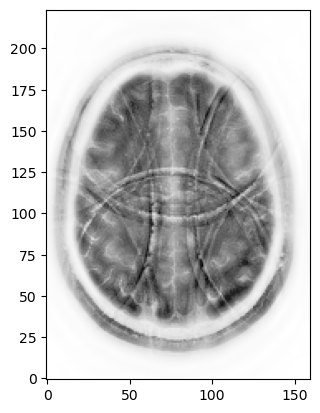

In [88]:
solver.next()

reco2 = smoother(solver.x)
brain= np.abs(normalize(*parallel_mri_op.domain.split(reco2)))
plt.imshow(brain,cmap=mplib.colormaps['Greys'],origin='lower')

### ... or run solver by stopping rule

In [77]:
#reco, reco_data = solver.run(stoprule)

2024-04-22 11:18:36,941 INFO CountIterations                          :: iteration = 0 / 8
2024-04-22 11:18:38,838 INFO TikhonovCG                               :: it.3 kappa=1.4718622081452757 err/Tol rel X:9.4e-01/2.5e-01 rel Y:2.4e-01/2.5e-01 
2024-04-22 11:18:38,842 INFO TikhonovCG                               :: Solver converged after 3 iteration.
2024-04-22 11:18:39,016 INFO CountIterations                          :: iteration = 1 / 8
2024-04-22 11:18:44,202 INFO TikhonovCG                               :: it.9 kappa=2.3970029794380885 err/Tol rel X:3.2e-01/2.5e-01 rel Y:2.2e-01/2.5e-01 
2024-04-22 11:18:44,207 INFO TikhonovCG                               :: Solver converged after 9 iteration.
2024-04-22 11:18:44,454 INFO CountIterations                          :: iteration = 2 / 8
2024-04-22 11:18:53,638 INFO TikhonovCG                               :: it.17 kappa=4.648273308358148 err/Tol rel X:2.3e-01/2.5e-01 rel Y:2.4e-01/2.5e-01 
2024-04-22 11:18:53,642 INFO TikhonovCG  